# Foundation Model: Chronos-T5-Base

**Outline**
1. Load data
2. Context window — walk-forward strategy
3. Walk-forward forecast: 30-day folds, expanding context
4. Forecast plot with 80% prediction interval and fold boundaries
5. Per-fold metrics, mean RMSE/MAE/MAPE, and leaderboard update
6. PI calibration check

---

A time series foundation model is a transformer pretrained on a large, diverse corpus of time series — Chronos was trained on approximately 600,000 real-world series augmented with synthetic data — and can generate forecasts for a new series without any model fitting. This is the defining contrast with every other model in this project: ETS, SARIMA, Prophet, and XGBoost each required parameter estimation or training on this specific household power dataset. Chronos treats forecasting as a language modeling task over quantized value tokens, sampling a distribution over future trajectories rather than producing a single point prediction.

## Step 0: Imports

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

import torch
from chronos import ChronosPipeline
from sklearn.metrics import mean_absolute_error

os.makedirs('../outputs', exist_ok=True)

## Step 1: Load Data

In [29]:
train = pd.read_csv('../data/daily_train.csv', index_col='datetime', parse_dates=True)
test  = pd.read_csv('../data/daily_test.csv',  index_col='datetime', parse_dates=True)

train_series = train['power']
test_series  = test['power']

print(f"Train: {train_series.index.min().date()} → {train_series.index.max().date()} ({len(train_series)} obs)")
print(f"Test:  {test_series.index.min().date()}  → {test_series.index.max().date()} ({len(test_series)} obs)")

Train: 2006-12-16 → 2009-11-30 (1081 obs)
Test:  2009-12-01  → 2010-11-26 (361 obs)


## Step 2: Context Window and Walk-Forward Strategy

Chronos takes the historical series as a *context* tensor — the analogue of a prompt in a language model.

**Context window:** `chronos-t5-base` has a maximum context window of 512 time steps. The training series is 1,081 days, so context is always capped at the most recent 512 observations.

**Walk-forward evaluation:** The test set is split into non-overlapping 30-day folds, matching the strategy used in all other notebooks. Before each fold, the actual observations from all prior folds are appended to the context (capped at 512), so the model always sees the most recent real data before it forecasts.

In [ ]:
MAX_CONTEXT = 512  # chronos-t5-base context limit
FOLD_SIZE   = 30
fold_starts = list(range(0, len(test_series), FOLD_SIZE))

print(f"Max context: {MAX_CONTEXT} obs")
print(f"Fold size:   {FOLD_SIZE} days  →  {len(fold_starts)} folds over {len(test_series)} test days")
print(f"Initial context end: {train_series.index[-1].date()}")

## Step 3: Walk-Forward Forecast

At each fold, `pipeline.predict` draws 100 sample paths of length 30. The context tensor is rebuilt from the rolling series (train + all prior test actuals, capped at `MAX_CONTEXT`), so the model's effective "memory" stays current throughout the test period. Median and 80% PI are extracted from the sample distribution at each fold and concatenated into full-length series.

In [ ]:
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-base",
    device_map="cpu",
    dtype=torch.float32,
)

rolling_series      = train_series.copy()
chronos_preds_list  = []
chronos_low_list    = []
chronos_high_list   = []

for i, start in enumerate(fold_starts):
    end      = min(start + FOLD_SIZE, len(test_series))
    fold_len = end - start

    ctx = torch.tensor(
        rolling_series.iloc[-MAX_CONTEXT:].values,
        dtype=torch.float32,
    )
    fc = pipeline.predict(ctx, prediction_length=fold_len, num_samples=100)

    fold_idx = test_series.index[start:end]
    # .median() returns a named tuple → need .values; .quantile() returns a plain tensor → no .values
    chronos_preds_list.append(pd.Series(fc[0].median(dim=0).values.numpy(), index=fold_idx))
    chronos_low_list.append(pd.Series(fc[0].quantile(0.1, dim=0).numpy(), index=fold_idx))
    chronos_high_list.append(pd.Series(fc[0].quantile(0.9, dim=0).numpy(), index=fold_idx))

    rolling_series = pd.concat([rolling_series, test_series.iloc[start:end]])
    print(f"  Chronos fold {i+1}/{len(fold_starts)}: days {start+1}–{end}")

chronos_forecast = pd.concat(chronos_preds_list)
chronos_low      = pd.concat(chronos_low_list)
chronos_high     = pd.concat(chronos_high_list)
print(f"\nCompleted {len(fold_starts)} folds covering {len(chronos_forecast)} test days")

## Step 4: Forecast Plot with 80% Prediction Interval

The walk-forward forecast covers the full test period. Dashed lines mark fold boundaries (every 30 days). The shaded band is the 80% prediction interval — the distinctive probabilistic output that no other model in the project produces.

In [ ]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((np.array(y_true) - np.array(y_pred)) ** 2))

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(train_series.iloc[-90:], color='steelblue', linewidth=0.8, label='Train (last 90d)')
ax.plot(test_series,             color='black',     linewidth=0.8, label='Actual')
ax.plot(chronos_forecast,        color='firebrick', linewidth=0.9, label='Forecast (median)')
ax.fill_between(
    chronos_forecast.index,
    chronos_low,
    chronos_high,
    color='firebrick', alpha=0.15, label='80% Prediction Interval',
)

for s in fold_starts[1:]:
    ax.axvline(x=test_series.index[s], color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

ax.set_ylabel('Power (kW)')
ax.set_title('Chronos-T5-Base — Walk-Forward Forecast (30-day folds, expanding context)')
ax.legend(fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig('../outputs/foundation_model_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ../outputs/foundation_model_forecast.png')

## Step 5: Metrics

In [ ]:
fold_rows = []
for i, start in enumerate(fold_starts):
    end = min(start + FOLD_SIZE, len(test_series))
    idx = test_series.index[start:end]
    act = test_series.loc[idx]
    fold_rows.append({
        'Fold': i + 1,
        'RMSE': rmse(act, chronos_forecast.loc[idx]),
        'MAE':  mean_absolute_error(act, chronos_forecast.loc[idx]),
        'MAPE': mape(act, chronos_forecast.loc[idx]),
    })

fold_df = pd.DataFrame(fold_rows).set_index('Fold').round(4)
display(fold_df)

metrics_fm = pd.DataFrame({
    'RMSE': [fold_df['RMSE'].mean()],
    'MAE':  [fold_df['MAE'].mean()],
    'MAPE': [fold_df['MAPE'].mean()],
}, index=['Chronos-T5-Base']).round(4)

print(f"\nMean across {len(fold_starts)} folds:")
print(metrics_fm.to_string())
metrics_fm.to_csv('../outputs/foundation_model_metrics.csv')
print('\nSaved → ../outputs/foundation_model_metrics.csv')

In [34]:
leaderboard_path = '../outputs/leaderboard.csv'

if os.path.exists(leaderboard_path):
    leaderboard = pd.read_csv(leaderboard_path, index_col=0)
    leaderboard = pd.concat([leaderboard, metrics_fm])
    leaderboard = leaderboard[~leaderboard.index.duplicated(keep='last')]
    leaderboard = leaderboard.sort_values('RMSE')
    leaderboard.to_csv(leaderboard_path)
    print('Updated → ../outputs/leaderboard.csv')
else:
    leaderboard = metrics_fm
    print('leaderboard.csv not found — run earlier notebooks first.')

display(
    leaderboard.style
    .format({'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'MAPE': '{:.2f}%'})
    .background_gradient(cmap='RdYlGn_r', subset=['RMSE', 'MAE', 'MAPE'])
    .set_caption('Model Leaderboard — sorted by RMSE (lower is better)')
)

Updated → ../outputs/leaderboard.csv


,RMSE,MAE,MAPE
XGBoost,0.2319,0.1815,19.01%
SARIMA,0.2381,0.1810,19.69%
Chronos-T5-Small,0.2503,0.1983,20.66%
Prophet,0.2547,0.1965,20.17%
ETS,0.2841,0.2317,23.99%


## Step 6: PI Calibration Check

A well-calibrated 80% prediction interval should contain approximately 80% of actual values. Coverage well above 80% means the bands are too wide (overconfident uncertainty); coverage well below 80% means the model is underestimating variance and the intervals cannot be trusted for risk assessment. Per-fold coverage shows whether calibration is consistent across the test period or degrades at certain horizons.

Overall 80% PI coverage: 48.5%  (target: 80.0%)


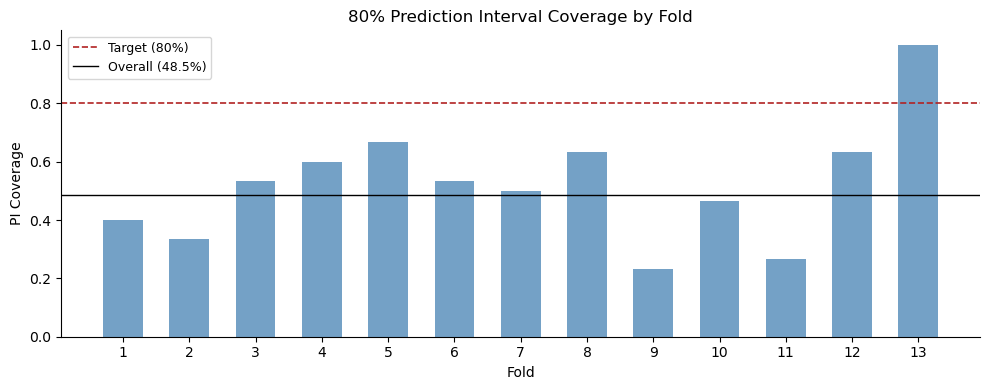

In [35]:
overall_coverage = ((test_series >= chronos_low) & (test_series <= chronos_high)).mean()
print(f"Overall 80% PI coverage: {overall_coverage:.1%}  (target: 80.0%)")

fold_coverage = []
for i, start in enumerate(fold_starts):
    end = min(start + FOLD_SIZE, len(test_series))
    idx = test_series.index[start:end]
    cov = ((test_series.loc[idx] >= chronos_low.loc[idx]) &
           (test_series.loc[idx] <= chronos_high.loc[idx])).mean()
    fold_coverage.append({'Fold': i + 1, 'Coverage': cov})

cov_df = pd.DataFrame(fold_coverage).set_index('Fold')

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(cov_df.index, cov_df['Coverage'], color='steelblue', alpha=0.75, width=0.6)
ax.axhline(0.80, color='firebrick', linestyle='--', linewidth=1.2, label='Target (80%)')
ax.axhline(overall_coverage, color='black', linestyle='-', linewidth=1.0,
           label=f'Overall ({overall_coverage:.1%})')
ax.set_xlabel('Fold')
ax.set_ylabel('PI Coverage')
ax.set_ylim(0, 1.05)
ax.set_xticks(cov_df.index)
ax.set_title('80% Prediction Interval Coverage by Fold')
ax.legend(fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()